# ▶️ LOADING AND CLEANING

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/bibianglez/first_project/refs/heads/main/data/raw/googleplaystore.csv")
df_review = pd.read_csv('https://raw.githubusercontent.com/bibianglez/first_project/refs/heads/main/data/raw/googleplaystore_user_reviews.csv')

## Google Play Store file

In [3]:
#Google play store info

df.shape
df.info()
df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [4]:
#cleanup

def clean_column_names(df):
    df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace(".", "_").str.lower()
    return df
clean_column_names(df)

def colum_values_lower(df):
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].str.lower().str.strip()
    return df
colum_values_lower(df)

# price to numeric
df['price'] = (df['price'].astype(str).str.replace('$', '', regex=False))
df['price'] = pd.to_numeric(df['price'], errors='coerce').fillna(0.0)
# rating column to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
#reviews column to numeric
df['reviews'] = pd.to_numeric(df['reviews'], errors='coerce')
#removing "free"
#df = df.loc[df["installs"] != "Free"]
#installs as int
df['installs'] = df['installs'].astype(str).str.replace('+', '', regex=False).str.replace(',', '', regex=False)
#df['installs'] = df['installs'].astype(int)
#removing duplicates
df.drop_duplicates(subset=['app'], keep='first', inplace=True)

df = df.loc[df["installs"] != "free"]
df['installs'] = df['installs'].astype(int)

display(df.shape)
display(df.info())
display(df.head(20))
display(df['app'].value_counts())

(9638, 13)

<class 'pandas.core.frame.DataFrame'>
Index: 9638 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   app             9638 non-null   object 
 1   category        9638 non-null   object 
 2   rating          8180 non-null   float64
 3   reviews         9638 non-null   float64
 4   size            9638 non-null   object 
 5   installs        9638 non-null   int64  
 6   type            9637 non-null   object 
 7   price           9638 non-null   float64
 8   content_rating  9638 non-null   object 
 9   genres          9638 non-null   object 
 10  last_updated    9638 non-null   object 
 11  current_ver     9630 non-null   object 
 12  android_ver     9636 non-null   object 
dtypes: float64(3), int64(1), object(9)
memory usage: 1.0+ MB


None

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
0,photo editor & candy camera & grid & scrapbook,art_and_design,4.1,159.0,19m,10000,free,0.0,everyone,art & design,"january 7, 2018",1.0.0,4.0.3 and up
1,coloring book moana,art_and_design,3.9,967.0,14m,500000,free,0.0,everyone,art & design;pretend play,"january 15, 2018",2.0.0,4.0.3 and up
2,"u launcher lite – free live cool themes, hide ...",art_and_design,4.7,87510.0,8.7m,5000000,free,0.0,everyone,art & design,"august 1, 2018",1.2.4,4.0.3 and up
3,sketch - draw & paint,art_and_design,4.5,215644.0,25m,50000000,free,0.0,teen,art & design,"june 8, 2018",varies with device,4.2 and up
4,pixel draw - number art coloring book,art_and_design,4.3,967.0,2.8m,100000,free,0.0,everyone,art & design;creativity,"june 20, 2018",1.1,4.4 and up
5,paper flowers instructions,art_and_design,4.4,167.0,5.6m,50000,free,0.0,everyone,art & design,"march 26, 2017",1.0,2.3 and up
6,smoke effect photo maker - smoke editor,art_and_design,3.8,178.0,19m,50000,free,0.0,everyone,art & design,"april 26, 2018",1.1,4.0.3 and up
7,infinite painter,art_and_design,4.1,36815.0,29m,1000000,free,0.0,everyone,art & design,"june 14, 2018",6.1.61.1,4.2 and up
8,garden coloring book,art_and_design,4.4,13791.0,33m,1000000,free,0.0,everyone,art & design,"september 20, 2017",2.9.2,3.0 and up
9,kids paint free - drawing fun,art_and_design,4.7,121.0,3.1m,10000,free,0.0,everyone,art & design;creativity,"july 3, 2018",2.8,4.0.3 and up


app
photo editor & candy camera & grid & scrapbook    1
infamy ro                                         1
ck coif                                           1
contract killer: zombies                          1
ck shop                                           1
                                                 ..
d day world war ii commando survival shooting     1
geometry dash meltdown                            1
koi live wallpaper                                1
kinemaster – pro video editor                     1
ihoroscope - 2018 daily horoscope & astrology     1
Name: count, Length: 9638, dtype: int64

## Reviews file

In [5]:
#reviews info

df_review.shape
df_review.info()
df_review.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.000000,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.250000,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.400000,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.000000,0.300000
5,10 Best Foods for You,Best way,Positive,1.000000,0.300000
6,10 Best Foods for You,Amazing,Positive,0.600000,0.900000
7,10 Best Foods for You,NaN,NaN,NaN,NaN
8,10 Best Foods for You,"Looking forward app,",Neutral,0.000000,0.000000
9,10 Best Foods for You,It helpful site ! It help foods get !,Neutral,0.000000,0.000000


In [6]:
#cleanup

def clean_column_names(df):
    df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace(".", "_").str.lower()
    return df
clean_column_names(df_review)

def colum_values_lower(df):
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].str.lower().str.strip()
    return df
colum_values_lower(df_review)
    
#overview after clueanup

display(df_review.shape)
print()
df_review.info()
print()
display(df_review['app'].value_counts())
print()
df_review.nunique().sum()
print()
display(df_review.head(20))
print()
unique_val_sentiment = df_review['sentiment'].unique()
total_unic = df_review['sentiment'].nunique()

print(f"unique values: {unique_val_sentiment}")
print(f"unique values: {total_unic}")

(64295, 5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   app                     64295 non-null  object 
 1   translated_review       37427 non-null  object 
 2   sentiment               37432 non-null  object 
 3   sentiment_polarity      37432 non-null  float64
 4   sentiment_subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB



app
angry birds classic                                  320
cbs sports app - scores, news, stats & watch live    320
bowmasters                                           320
8 ball pool                                          300
helix jump                                           300
                                                    ... 
easy healthy recipes                                  31
dresses ideas & fashions +3000                        31
detector de radares gratis                            31
easy hair style design                                30
drawing clothes fashion ideas                         30
Name: count, Length: 1074, dtype: int64

,app,translated_review,sentiment,sentiment_polarity,sentiment_subjectivity
0,10 best foods for you,i like eat delicious food. that's i'm cooking ...,positive,1.000000,0.533333
1,10 best foods for you,this help eating healthy exercise regular basis,positive,0.250000,0.288462
2,10 best foods for you,NaN,NaN,NaN,NaN
3,10 best foods for you,works great especially going grocery store,positive,0.400000,0.875000
4,10 best foods for you,best idea us,positive,1.000000,0.300000
5,10 best foods for you,best way,positive,1.000000,0.300000
6,10 best foods for you,amazing,positive,0.600000,0.900000
7,10 best foods for you,NaN,NaN,NaN,NaN
8,10 best foods for you,"looking forward app,",neutral,0.000000,0.000000
9,10 best foods for you,it helpful site ! it help foods get !,neutral,0.000000,0.000000



unique values: ['positive' nan 'neutral' 'negative']
unique values: 3


# ▶️ ANALYSIS

## Google play dataframe

In [35]:
#how many categories there are and how popular are each
categories_top = df['category'].value_counts()
display(categories_top)

# top 25 installed apps
top_25_installs = df.nlargest(25, 'installs')
display(top_25_installs[['app', 'installs','genres']].sort_values(by='genres').style.set_caption("Top 25 by downloads"))

print()

top_25_rating = df.nlargest(25, 'rating')
display(top_25_rating[['app', 'rating','genres']].sort_values(by='genres').style.set_caption("Top 25 by Rating"))

print()

# top5 morst downloaded genre
top_5_genre = df['genres'].value_counts().head(10)
display(top_5_genre.to_frame().style.set_caption("Top 10 downloaded by genre"))

print()

#paid vs free apps?
paid_vs_free = df.groupby('type').agg(apps_nr=('type', 'count'),total_downloads=('installs', 'sum'))

total_downloads = df['installs'].sum()
total_apps = paid_vs_free['apps_nr'].sum()  

paid_vs_free['apps_perc'] = (paid_vs_free['apps_nr'] / total_apps) * 100
paid_vs_free['downloads_perc'] = (paid_vs_free['total_downloads'] / total_downloads) * 100

display(paid_vs_free.style.set_caption("paid vs free apps").format({'total_downloads': '{:,.0f}','apps_perc': '{:.2f}%','downloads_perc': '{:.2f}%'}))

print()

#apps with more income (removing the "I am rich" ones)
df['gain'] = df['installs'] * df['price']

df_paid = df[(df['type'] == 'paid')& (df['gain'] > 0)& (~df['app'].str.contains('rich', case=False, na=False))]
top_10_income = df_paid.nlargest(10, 'gain')
display(top_10_income[['app', 'installs', 'price', 'gain']].style.set_caption("TOP 10 apps with more revenew"))

category
family                 1827
game                    957
tools                   824
business                419
medical                 394
personalization         375
productivity            374
lifestyle               369
finance                 342
sports                  325
communication           315
health_and_fitness      287
photography             279
news_and_magazines      254
social                  238
books_and_reference     222
travel_and_local        219
shopping                202
dating                  171
video_players           163
maps_and_navigation     131
education               119
food_and_drink          111
entertainment           102
auto_and_vehicles        85
libraries_and_demo       84
weather                  79
house_and_home           74
events                   64
art_and_design           64
parenting                60
comics                   56
beauty                   53
Name: count, dtype: int64

,app,installs,genres
1654,subway surfers,1000000000,arcade
152,google play books,1000000000,books & reference
371,google duo - high quality video calls,500000000,communication
347,imo free video calls and chat,500000000,communication
342,viber messenger,500000000,communication
378,uc browser - fast download private & secure,500000000,communication
403,line: free calls & messages,500000000,communication
341,hangouts,1000000000,communication
335,messenger – text and video chat for free,1000000000,communication
336,whatsapp messenger,1000000000,communication


,app,rating,genres
329,hojiboy tojiboyev life hacks,5.000000,comics
612,american girls mobile numbers,5.000000,dating
615,awake dating,5.000000,dating
633,spine- the dating app,5.000000,dating
636,girls live talk - free text and video chat,5.000000,dating
640,online girls chat group,5.000000,dating
654,speeding joyride & car meet app,5.000000,dating
1038,mindvalley u tallinn 2018,5.000000,events
1030,prosperity,5.000000,events
1028,summer sonic app,5.000000,events


,count
genres,
tools,823
entertainment,557
education,509
business,419
medical,394
personalization,375
productivity,374
lifestyle,368
finance,342


,apps_nr,total_downloads,apps_perc,downloads_perc
type,,,,
free,8884,"74,948,435,336",92.19%,99.92%
paid,753,"57,349,881",7.81%,0.08%


,app,installs,price,gain
2241,minecraft,10000000,6.990000,69900000.000000
4034,hitman sniper,10000000,0.990000,9900000.000000
7417,grand theft auto: san andreas,1000000,6.990000,6990000.000000
2883,facetune - for free,1000000,5.990000,5990000.000000
5578,sleep as android unlock,1000000,5.990000,5990000.000000
8804,drastic ds emulator,1000000,4.990000,4990000.000000
4133,weather live,500000,5.990000,2995000.000000
2242,card wars - adventure time,1000000,2.990000,2990000.000000
5631,five nights at freddy's,1000000,2.990000,2990000.000000
7355,threema,1000000,2.990000,2990000.000000


## Reviews dataframe

In [8]:
# numer of apps
#df_review['app'].nunique() 
#print(f"the number of apps with reviews is ",df_review['app'].nunique())
#print()

# numer of reviews per app
#df_reviews_by_app = df_review.groupby('app').size().reset_index(name='total_reviews').sort_values(by='total_reviews', ascending=False).head(25)
##display(df_reviews_by_app.style.set_caption("number of reviews per app - top 25"))
#print()

#apps with most positive sentiment
#df_positive = df_review[df_review['sentiment'] == 'positive']
#df_reviews_positive = (df_positivas.groupby('app').size().reset_index(name='positive_reviews').sort_values(by='positive_reviews', #ascending=False).head(25))
#display(df_reviews_positive.style.set_caption("apps with most positive reviews"))

#df_total_reviews = df_reviews_by_app[['app', 'total_reviews']]
#df_result = pd.merge(df_reviews_positive, df_total_reviews, on='app', how='left')
#df_result['positive_ratio'] = (df_result['positive_reviews'] / df_result['total_reviews']) * 100
#df_top_positive = df_result.sort_values(by='positive_ratio', ascending=False).head(25)
#display(df_top_positive.style
    #.set_caption("apps with most positive reviews (including total reviews)")
    #.format({'positive_reviews': '{:.0f}', 'positive_ratio': '{:.2f}%', 'total_reviews': '{:.0f}'}, na_rep='N/A'))

In [9]:
# Crossed table 

df_sentiment_counts = pd.crosstab(df_review['app'], df_review['sentiment']).reset_index()
df_sentiment_counts = df_sentiment_counts[['app', 'positive', 'neutral', 'negative']]

total_sentiments = df_sentiment_counts['positive'] + df_sentiment_counts['neutral'] + df_sentiment_counts['negative']

df_sentiment_counts['%_positive'] = (df_sentiment_counts['positive'] / total_sentiments) * 100

df_sentiment_counts = df_sentiment_counts.sort_values(by='positive', ascending=False)
display(
    df_sentiment_counts.style
    .set_caption("Sentiment by application")
    .format({
        'positive': '{:.0f}',
        'neutral': '{:.0f}',
        'negative': '{:.0f}',
    }, na_rep='N/A')
)

sentiment,app,positive,neutral,negative,%_positive
802,helix jump,209,6,58,76.556777
510,duolingo: learn languages free,200,6,34,83.333333
310,calorie counter - macros,174,6,20,87.000000
255,bowmasters,169,24,119,54.166667
311,calorie counter - myfitnesspal,169,34,52,66.274510
0,10 best foods for you,162,22,10,83.505155
743,google photos,143,1,47,74.869110
24,8fit workouts & meal planner,137,15,19,80.116959
699,garena free fire,136,5,81,61.261261
487,dragon ball legends,127,1,39,76.047904


# ▶️ Merge by reviews apps

In [10]:
#average of

#df_total_reviews = df_review.groupby('app').size().reset_index(name='total_reviews')

#df_positive = df_review[df_review['sentiment'] == 'positive']
#df_reviews_positive = df_positive.groupby('app').size().reset_index(name='positive_reviews')

df_reviews_resume = pd.merge(df_sentiment_counts, df, on='app', how='inner')


columnas_df = ['app', 'category', 'rating', 'reviews', 'installs', 'price', 'genres']

df_final = pd.merge(df_reviews_resume,df[columnas_df],on='app', 
                    #how='left')
                   how='inner')
display(df_final.head(50))


,app,positive,neutral,negative,%_positive,category_x,rating_x,reviews_x,size,installs_x,...,last_updated,current_ver,android_ver,gain,category_y,rating_y,reviews_y,installs_y,price_y,genres_y
0,helix jump,209,6,58,76.556777,game,4.2,1497361.0,33m,100000000,...,"april 9, 2018",1.0.6,4.1 and up,0.0,game,4.2,1497361.0,100000000,0.00,action
1,duolingo: learn languages free,200,6,34,83.333333,education,4.7,6289924.0,varies with device,100000000,...,"august 1, 2018",varies with device,varies with device,0.0,education,4.7,6289924.0,100000000,0.00,education;education
2,calorie counter - macros,174,6,20,87.000000,health_and_fitness,4.0,3061.0,5.5m,100000,...,"august 27, 2016",2.3.4,5.0 and up,0.0,health_and_fitness,4.0,3061.0,100000,0.00,health & fitness
3,bowmasters,169,24,119,54.166667,game,4.7,1534466.0,varies with device,50000000,...,"july 23, 2018",2.12.5,4.1 and up,0.0,game,4.7,1534466.0,50000000,0.00,action
4,calorie counter - myfitnesspal,169,34,52,66.274510,health_and_fitness,4.6,1873516.0,varies with device,50000000,...,"july 31, 2018",varies with device,varies with device,0.0,health_and_fitness,4.6,1873516.0,50000000,0.00,health & fitness
5,10 best foods for you,162,22,10,83.505155,health_and_fitness,4.0,2490.0,3.8m,500000,...,"february 17, 2017",1.9,2.3.3 and up,0.0,health_and_fitness,4.0,2490.0,500000,0.00,health & fitness
6,google photos,143,1,47,74.869110,photography,4.5,10858556.0,varies with device,1000000000,...,"august 6, 2018",varies with device,varies with device,0.0,photography,4.5,10858556.0,1000000000,0.00,photography
7,8fit workouts & meal planner,137,15,19,80.116959,health_and_fitness,4.6,115721.0,67m,10000000,...,"july 11, 2018",3.5.0,5.0 and up,0.0,health_and_fitness,4.6,115721.0,10000000,0.00,health & fitness
8,garena free fire,136,5,81,61.261261,game,4.5,5465624.0,53m,100000000,...,"august 3, 2018",1.21.0,4.0.3 and up,0.0,game,4.5,5465624.0,100000000,0.00,action
9,dragon ball legends,127,1,39,76.047904,game,4.6,337752.0,48m,5000000,...,"august 3, 2018",1.11.0,6.0 and up,0.0,game,4.6,337752.0,5000000,0.00,action


In [11]:
df_reviews_resume.head()

,app,positive,neutral,negative,%_positive,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver,gain
0,helix jump,209,6,58,76.556777,game,4.2,1497361.0,33m,100000000,free,0.0,everyone,action,"april 9, 2018",1.0.6,4.1 and up,0.0
1,duolingo: learn languages free,200,6,34,83.333333,education,4.7,6289924.0,varies with device,100000000,free,0.0,everyone,education;education,"august 1, 2018",varies with device,varies with device,0.0
2,calorie counter - macros,174,6,20,87.000000,health_and_fitness,4.0,3061.0,5.5m,100000,free,0.0,everyone,health & fitness,"august 27, 2016",2.3.4,5.0 and up,0.0
3,bowmasters,169,24,119,54.166667,game,4.7,1534466.0,varies with device,50000000,free,0.0,teen,action,"july 23, 2018",2.12.5,4.1 and up,0.0
4,calorie counter - myfitnesspal,169,34,52,66.274510,health_and_fitness,4.6,1873516.0,varies with device,50000000,free,0.0,everyone,health & fitness,"july 31, 2018",varies with device,varies with device,0.0


# ▶️ GRAPHS

## Google play graphs

C:\Users\fotos\AppData\Local\Temp\ipykernel_12968\935333157.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Apps_nr', y='cATEGORY', data=cat_counts,


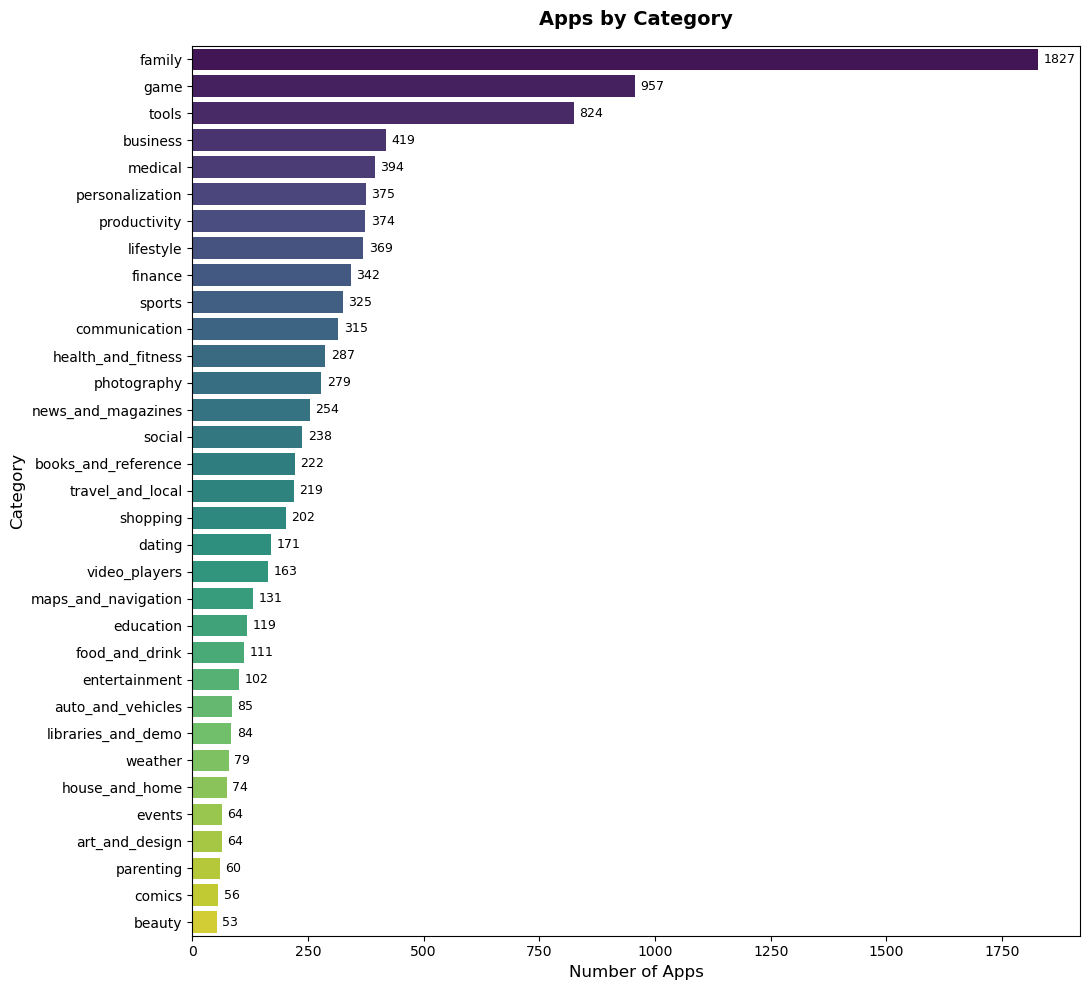

In [12]:
def plot_apps_by_category(df: pd.DataFrame) -> None:
    cat_counts = (df['category'].value_counts()
                  .reset_index()
                  .rename(columns={'index': 'Categoría', 'category': 'Cantidad_Apps'}))
    cat_counts.columns = ['cATEGORY', 'Apps_nr']

    fig, ax = plt.subplots(figsize=(11, 10))
    sns.barplot(x='Apps_nr', y='cATEGORY', data=cat_counts,
                palette='viridis', ax=ax)

    for i, v in enumerate(cat_counts['Apps_nr']):
        ax.text(v + 12, i, str(v), color='black', fontsize=9, va='center')

    ax.set_title('Apps by Category', fontsize=14, weight='bold', pad=15)
    ax.set_xlabel('Number of Apps', fontsize=12)
    ax.set_ylabel('Category', fontsize=12)
    plt.tight_layout()
    plt.show()
plot_apps_by_category(df)



(3.0, 5.0)

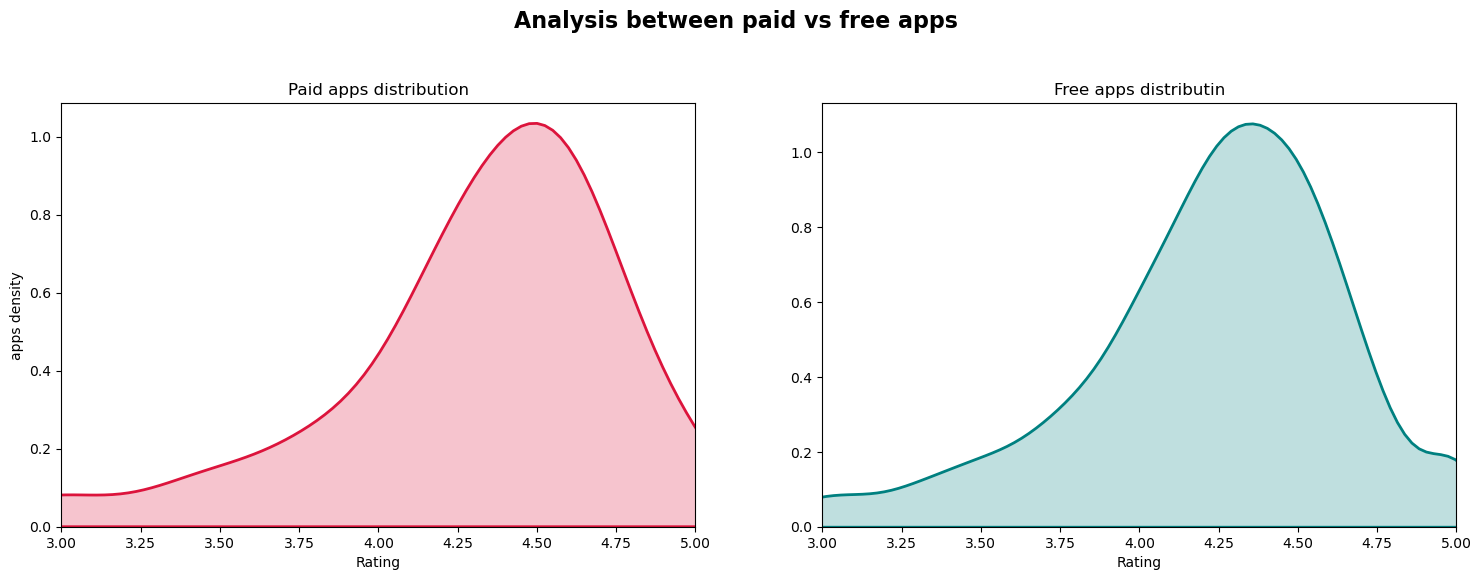

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))
fig.suptitle('Analysis between paid vs free apps', fontsize=16, weight='bold', y=1.05)

df_clean_rating = df.dropna(subset=['rating'])

sns.kdeplot(
    data=df_clean_rating[df_clean_rating['type'] == 'paid'], 
    x='rating', fill=True, color='crimson', ax=axes[0], linewidth=2
)
axes[0].set_title('Paid apps distribution', fontsize=12)
axes[0].set_xlabel('Rating', fontsize=10)
axes[0].set_ylabel('apps density', fontsize=10)
axes[0].set_xlim(3.0, 5.0)  

sns.kdeplot(
    data=df_clean_rating[df_clean_rating['type'] == 'free'], 
    x='rating', fill=True, color='teal', ax=axes[1], linewidth=2
)
axes[1].set_title('Free apps distributin', fontsize=12)
axes[1].set_xlabel('Rating', fontsize=10)
axes[1].set_ylabel('') 
axes[1].set_xlim(3.0, 5.0) 

C:\Users\fotos\AppData\Local\Temp\ipykernel_12968\194460089.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_rating['rating_range'] = pd.cut(df_clean_rating['rating'], bins=bins, labels=labels)


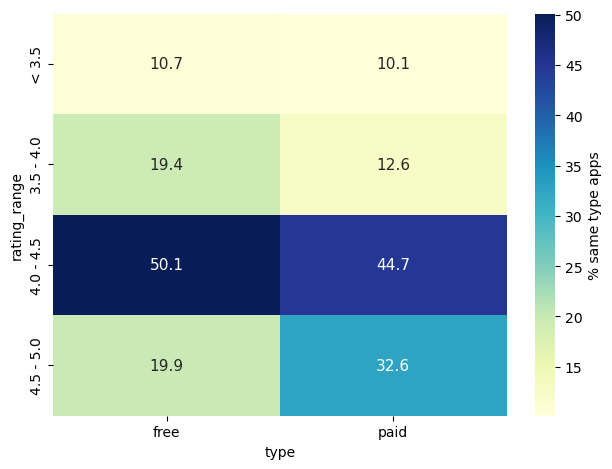

In [14]:
bins = [0, 3.5, 4.0, 4.5, 5.0]
labels = ['< 3.5', '3.5 - 4.0', '4.0 - 4.5', '4.5 - 5.0']
df_clean_rating['rating_range'] = pd.cut(df_clean_rating['rating'], bins=bins, labels=labels)
heatmap_data = pd.crosstab(df_clean_rating['rating_range'], df_clean_rating['type'], normalize='columns') * 100

sns.heatmap(
    heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", 
    cbar_kws={'label': '% same type apps'}, annot_kws={"size": 11}
)
axes[0].set_title('ratings concentration', fontsize=12)
axes[0].set_xlabel('apps type', fontsize=10)
axes[0].set_ylabel('Rating', fontsize=10)
axes[0].invert_yaxis()
plt.tight_layout()
plt.show()

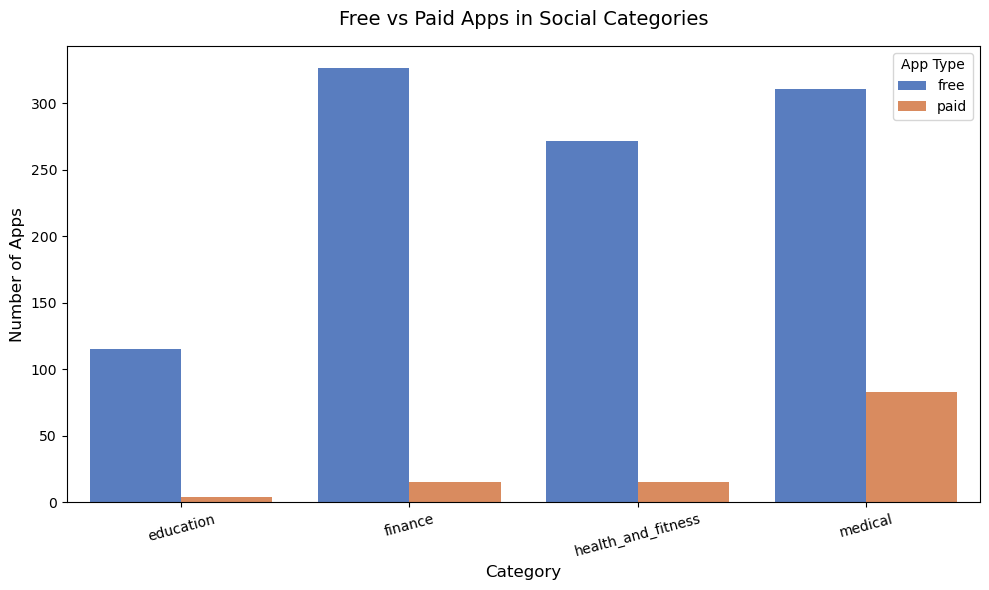

In [16]:
def plot_free_vs_paid_social(df: pd.DataFrame,
                              categories: list = None) -> None:
    if categories is None:
        categories = ['health_and_fitness', 'medical',
                      'education', 'finance', 'commuication']

    df_filt = df[df['category'].isin(categories)]
    plt.figure(figsize=(10, 6))
    sns.countplot(x='category', hue='type', data=df_filt, palette='muted')
    plt.title('Free vs Paid Apps in Social Categories', fontsize=14, pad=15)
    plt.xlabel('Category', fontsize=12)
    plt.ylabel('Number of Apps', fontsize=12)
    plt.xticks(rotation=15)
    plt.legend(title='App Type')
    plt.tight_layout()
    plt.show()
plot_free_vs_paid_social(df)

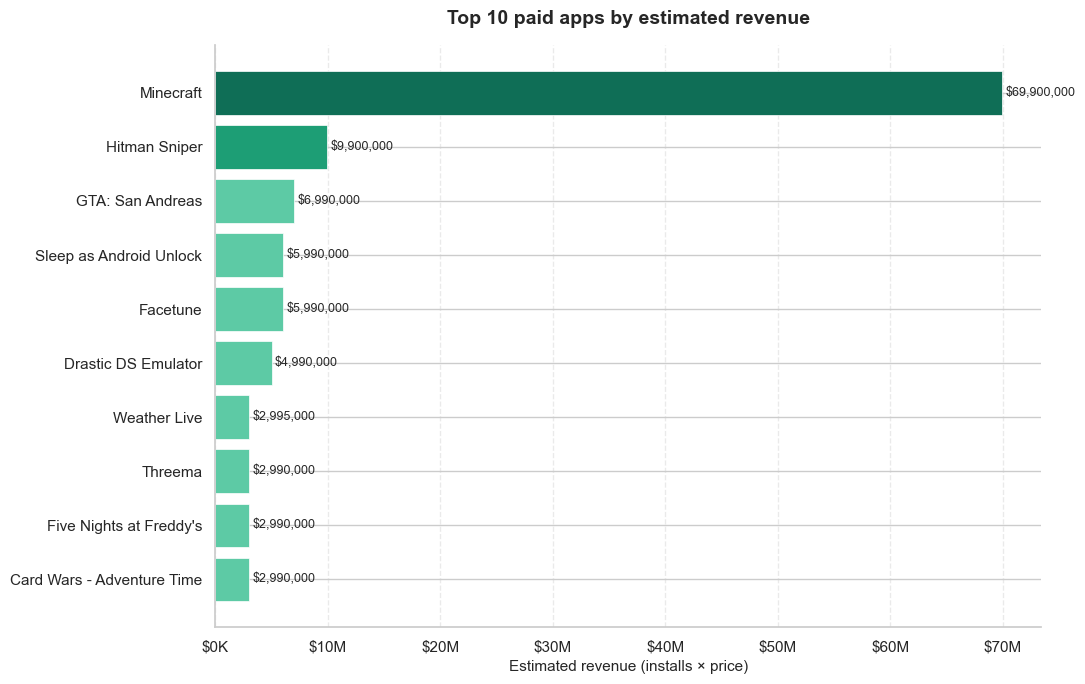

In [36]:
data = {
    'app': [
        'Minecraft', 'Hitman Sniper', 'GTA: San Andreas',
        'Facetune', 'Sleep as Android Unlock', 'Drastic DS Emulator',
        'Weather Live', 'Card Wars - Adventure Time',
        "Five Nights at Freddy's", 'Threema'
    ],
    'installs': [10000000,10000000,1000000,1000000,1000000,
                 1000000,500000,1000000,1000000,1000000],
    'price':   [6.99, 0.99, 6.99, 5.99, 5.99,
                4.99, 5.99, 2.99, 2.99, 2.99],
    'gain':    [69900000,9900000,6990000,5990000,5990000,
                4990000,2995000,2990000,2990000,2990000]
}

df = pd.DataFrame(data).sort_values('gain', ascending=True)

colors = ['#0f6e56' if i == len(df)-1 else '#1d9e75' if i == len(df)-2 else '#5dcaa5'
          for i in range(len(df))]

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(df['app'], df['gain'], color=colors, edgecolor='white', linewidth=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 300000, bar.get_y() + bar.get_height() / 2,
            f'${width:,.0f}', va='center', fontsize=9)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${int(x/1_000_000)}M' if x >= 1_000_000 else f'${int(x/1000)}K'))

ax.set_title('Top 10 paid apps by estimated revenue', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Estimated revenue (installs × price)', fontsize=11)
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('top10_paid_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## Gender segmentation

apps in the women's pattern:238
apps in the men's pattern:347


,app,category,rating,installs,target_gender
21,boys photo editor - six pack & men's suit,art_and_design,4.1,100000,Men-focused
40,drawing clothes fashion ideas,art_and_design,4.2,10000,Women-focused
49,monster truck stunt 3d 2019,auto_and_vehicles,4.2,100000,Men-focused
51,ultimate f1 racing championship,auto_and_vehicles,3.8,100000,Men-focused
52,used cars and trucks for sale,auto_and_vehicles,4.6,1000000,Men-focused
53,american muscle car race,auto_and_vehicles,3.9,100000,Men-focused
54,offroad oil tanker driver transport truck 2019,auto_and_vehicles,4.3,100000,Men-focused
63,free vin report for used cars,auto_and_vehicles,4.6,100000,Men-focused
66,used cars mexico,auto_and_vehicles,4.0,50000,Men-focused
69,used cars for sale - trovit,auto_and_vehicles,4.2,5000000,Men-focused


C:\Users\fotos\AppData\Local\Temp\ipykernel_12968\697277501.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\fotos\AppData\Local\Temp\ipykernel_12968\697277501.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


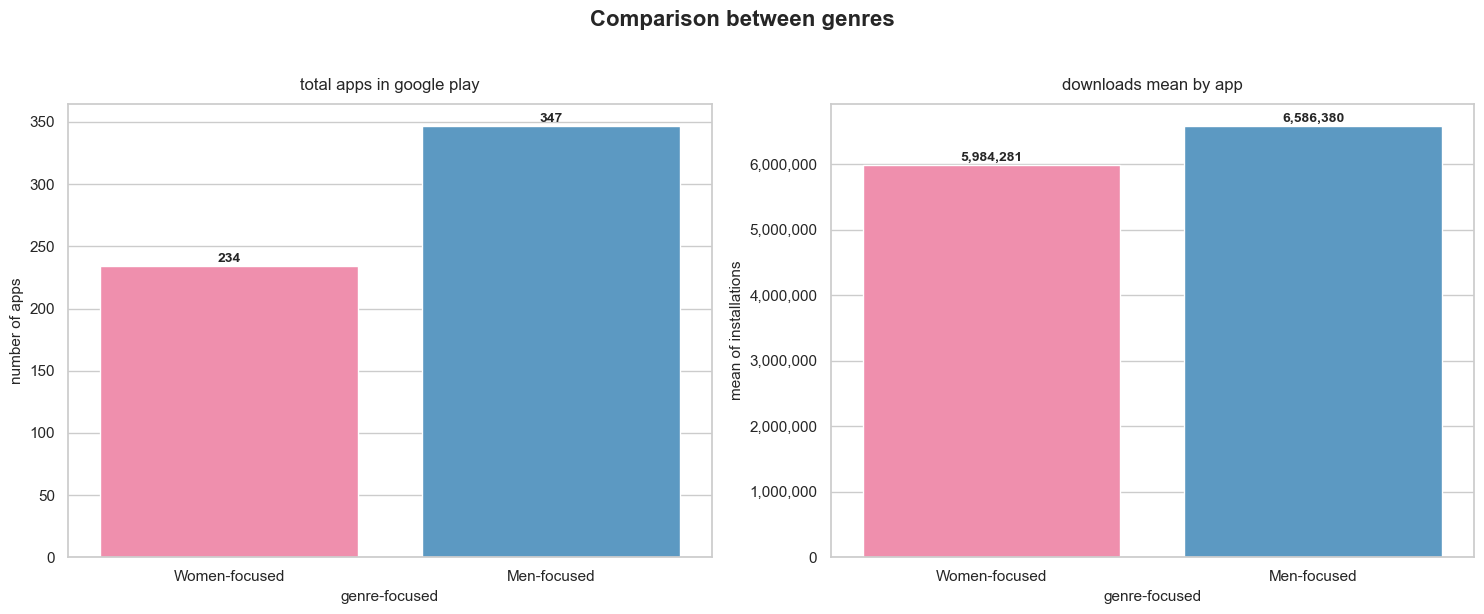

In [27]:
# now I?m going to try to find apps that are aiming for male and/or female public by using stereotipical words. 25 words each

keywords_women = ['period', 'ovulation', 'pregnancy', 'makeup', 'nails', 'female', 'girl', 'women', 'hair', 'blw', 'baby', 'hairstyle', 'beauty', 'Dresses', 'maternity', "nursing", 'diet', "breastfeeding",'pilates', 'yoga', 'weight', 'diet', 'wrinkle', 'fashion', 'wedding']
keywords_men = ['beard', 'shaving', 'barber', 'testosterone', 'male', 'boy', 'men\'s', 'Football', 'soccer', 'sport', 'sports', 'golf', 'invest', 'investment','body builder', 'bodybuilding', 'muscle', 'boxing', 'NBA', 'gun', 'cars', 'truck', 'f1', 'race', 'racing']


women_pattern = '|'.join(keywords_women) 
men_pattern = '|'.join(keywords_men)

df_women = df[df['app'].str.contains(women_pattern, case=False, na=False)]
df_men = df[df['app'].str.contains(men_pattern, case=False, na=False)]

print(f"apps in the women's pattern:{len(df_women)}")
print(f"apps in the men's pattern:{len(df_men)}")

df_gender = df.drop_duplicates(subset=['app']).copy()

women_focused = df_gender['app'].str.contains(women_pattern, case=False, na=False)
men_focused = df_gender['app'].str.contains(men_pattern, case=False, na=False)

df_gender['target_gender'] = 'General'

df_gender.loc[women_focused, 'target_gender'] = 'Women-focused'
df_gender.loc[men_focused, 'target_gender'] = 'Men-focused'


df_segmented = df_gender[df_gender['target_gender'] != 'General'].copy()

columns_to_show = ['app', 'category', 'rating', 'installs', 'target_gender']
display(df_segmented[columns_to_show].head(10))


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Comparison between genres', fontsize=16, weight='bold', y=1.02)
sns.set_theme(style="whitegrid")


order_gender = ['Women-focused', 'Men-focused']
sns.countplot(
    data=df_segmented, 
    x='target_gender', 
    palette=['#ff7fa7', '#4b9cd3'], 
    order=order_gender,
    ax=axes[0]
)
axes[0].set_title('total apps in google play', fontsize=12, pad=10)
axes[0].set_xlabel('genre-focused', fontsize=11)
axes[0].set_ylabel('number of apps', fontsize=11)

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, weight='bold')


sns.barplot(
    data=df_segmented, 
    x='target_gender', 
    y='installs', 
    palette=['#ff7fa7', '#4b9cd3'], 
    order=order_gender,
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title('downloads mean by app', fontsize=12, pad=10)
axes[1].set_xlabel('genre-focused', fontsize=11)
axes[1].set_ylabel('mean of installations', fontsize=11)

axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

## Reviews 

C:\Users\fotos\AppData\Local\Temp\ipykernel_12968\3714562763.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values,


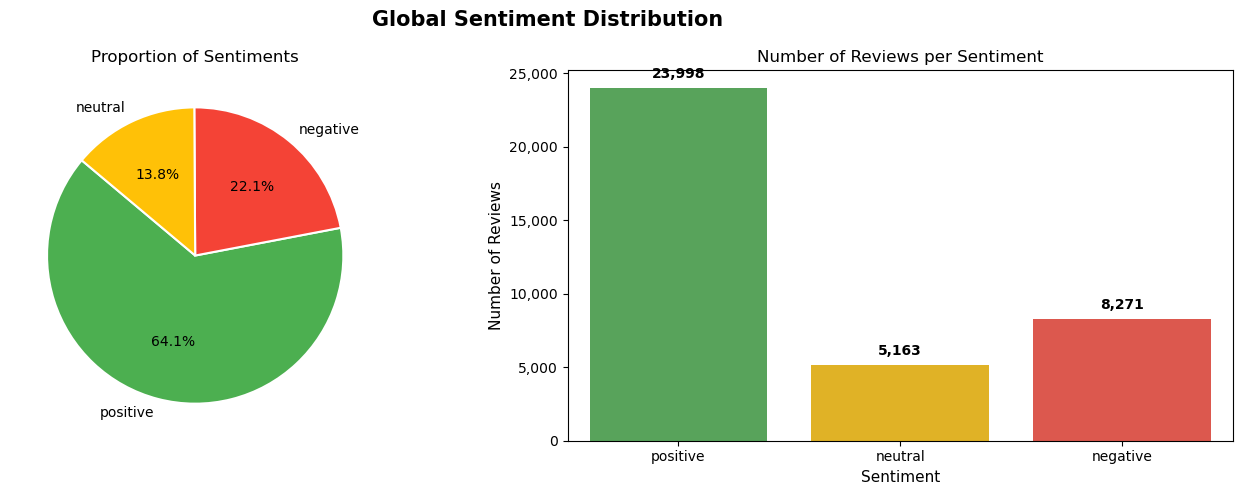

In [19]:
counts = df_review['sentiment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Global Sentiment Distribution', fontsize=15, weight='bold')

# Pie
palette = {'positive': '#4caf50', 'neutral': '#ffc107', 'negative': '#f44336'}
colors  = [palette.get(s, '#90a4ae') for s in counts.index]

axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Proportion of Sentiments', fontsize=12)

# Barplot
sns.barplot(x=counts.index, y=counts.values,
            palette=palette, ax=axes[1], order=['positive', 'neutral', 'negative'])

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', xytext=(0, 5),
                     textcoords='offset points', fontsize=10, weight='bold')

axes[1].set_title('Number of Reviews per Sentiment', fontsize=12)
axes[1].set_xlabel('Sentiment', fontsize=11)
axes[1].set_ylabel('Number of Reviews', fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

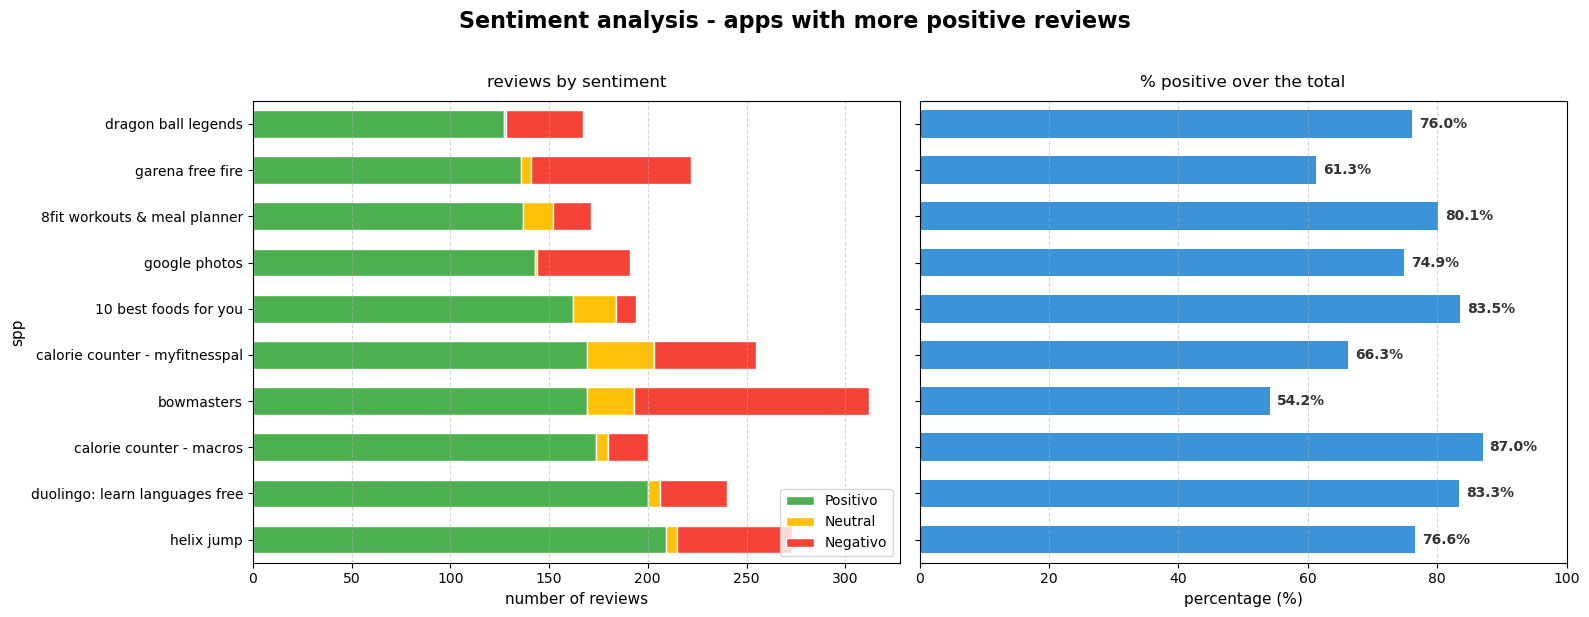

In [20]:
top_10_apps = df_sentiment_counts.head(10).copy()

top_10_apps = top_10_apps.iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Sentiment analysis - apps with more positive reviews', fontsize=16, weight='bold', y=1.02)

colores = ['#4caf50', '#ffc107', '#f44336'] 

top_10_apps.set_index('app')[['positive', 'neutral', 'negative']].plot(
    kind='barh', 
    stacked=True, 
    color=colores, 
    ax=axes[0], 
    width=0.6,
    edgecolor='white',
    linewidth=1
)
axes[0].set_title('reviews by sentiment', fontsize=12, pad=10)
axes[0].set_xlabel('number of reviews', fontsize=11)
axes[0].set_ylabel('spp', fontsize=11)
axes[0].legend(['Positivo', 'Neutral', 'Negativo'], loc='lower right')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)


sns.barplot(
    x='%_positive', 
    y='app', 
    data=top_10_apps, 
    color='#2196f3', 
    ax=axes[1],
    width=0.6
)
axes[1].set_title('% positive over the total', fontsize=12, pad=10)
axes[1].set_xlabel('percentage (%)', fontsize=11)
axes[1].set_ylabel('') 
axes[1].set_xlim(0, 100) 
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

for p in axes[1].patches:
    width = p.get_width()
    if width > 0: 
        axes[1].annotate(f'{width:.1f}%',
                         (width, p.get_y() + p.get_height() / 2),
                         ha='left', va='center', 
                         xytext=(5, 0), textcoords='offset points', 
                         fontsize=10, weight='bold', color='#333333')

plt.tight_layout()
plt.show()

# CONCLUSION - SUCCESSFUL APPS

In [24]:
counts_category = df['category'].value_counts()
small_categories = counts_category[counts_category < 400].index

filtered_apps = df[
    (df['category'].isin(small_categories)) &  
    (df['installs'] > 5000000) &             
    (df['rating'] > 4.5)                      
]

result = filtered_apps.sort_values(by='reviews', ascending=False)

columns_to_show = ['app', 'category', 'rating', 'reviews', 'installs','price']
display(result[columns_to_show])

,app,category,rating,reviews,installs,price
4688,vivavideo - video editor & photo movie,video_players,4.6,9879473.0,100000000,0.0
2943,"photogrid: video & pic collage maker, photo ed...",photography,4.6,7529865.0,100000000,0.0
3820,"waze - gps, maps, traffic alerts & live naviga...",maps_and_navigation,4.6,7232629.0,100000000,0.0
3360,"cm launcher 3d - theme, wallpapers, efficient",personalization,4.6,6702776.0,100000000,0.0
3354,zedge™ ringtones & wallpapers,personalization,4.6,6466641.0,100000000,0.0
...,...,...,...,...,...,...
2668,flipp - weekly shopping,shopping,4.6,85858.0,10000000,0.0
1344,headspace: meditation & mindfulness,health_and_fitness,4.6,77563.0,10000000,0.0
4862,abs workout - burn belly fat with no equipment,health_and_fitness,4.8,69279.0,10000000,0.0
4603,at&t mobile transfer,productivity,4.6,22775.0,10000000,0.0


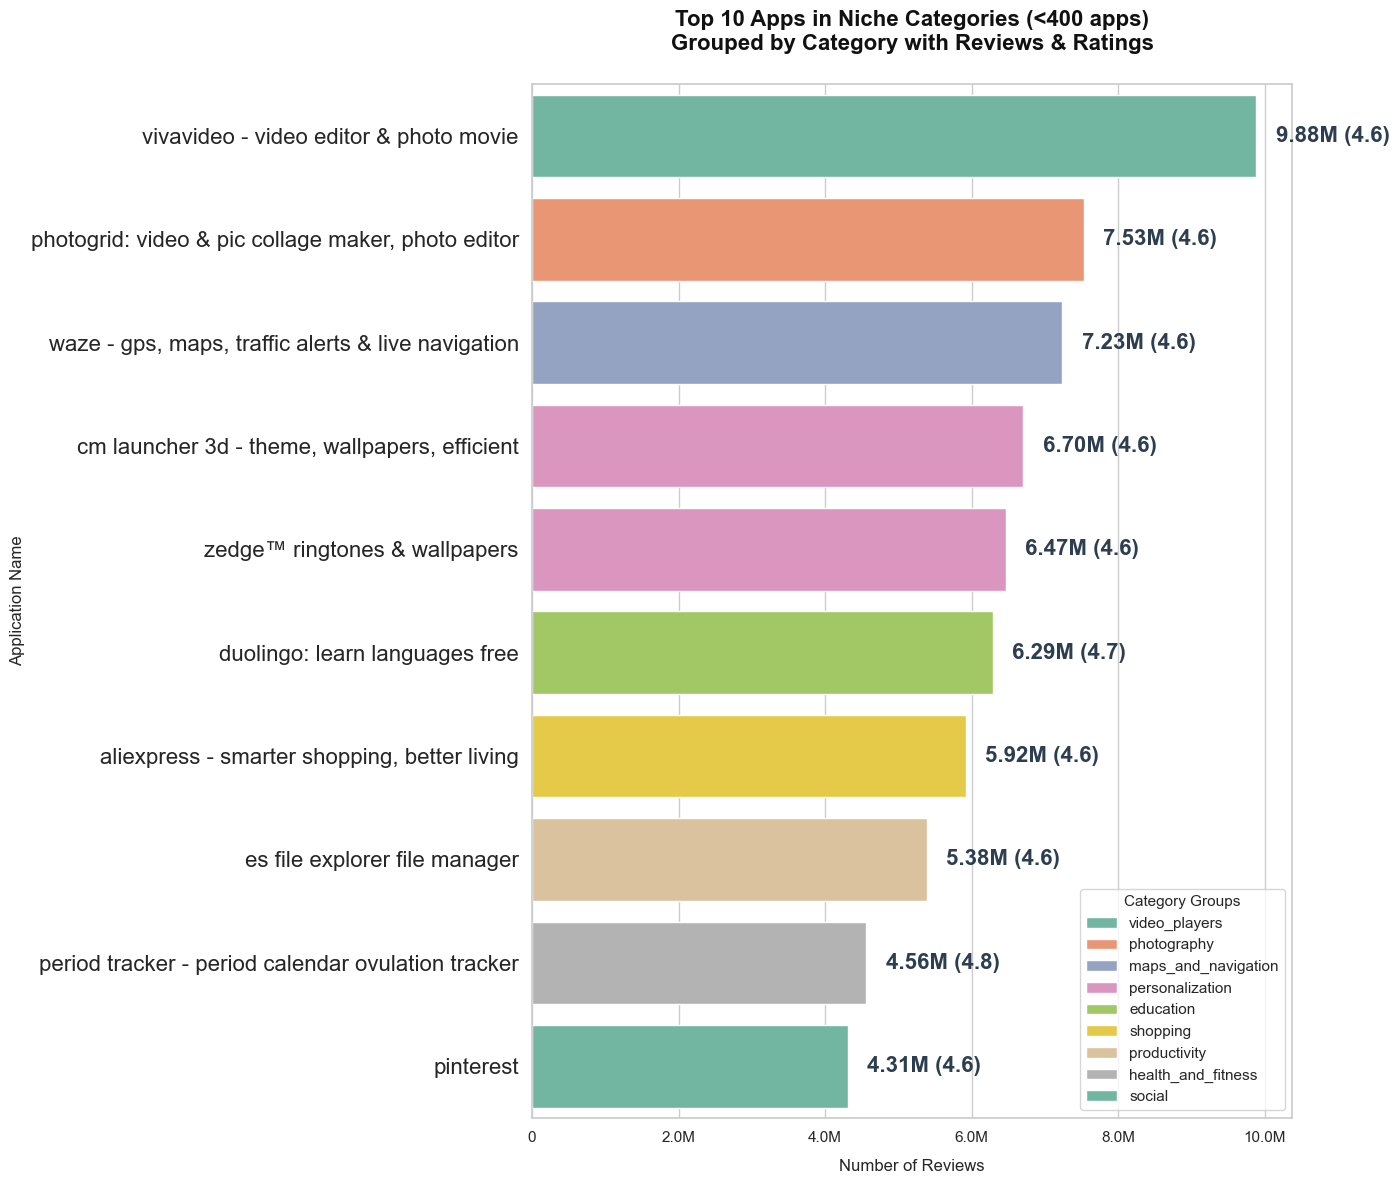

In [34]:
top_10_apps = result.drop_duplicates(subset=['app']).head(10)

top_10_complex = result.drop_duplicates(subset=['app']).head(10)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 12))


norm = plt.Normalize(top_10_complex['rating'].min(), top_10_complex['rating'].max())
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)


categories = top_10_complex['category'].unique()
palette_colors = sns.color_palette("Set2", len(categories))
category_palette = dict(zip(categories, palette_colors))

ax = sns.barplot(
    x='reviews', 
    y='app', 
    hue='category',
    data=top_10_complex, 
    palette=category_palette,
    dodge=False 
)

plt.title('Top 10 Apps in Niche Categories (<400 apps)\nGrouped by Category with Reviews & Ratings', 
          fontsize=16, pad=25, weight='bold', color='#111111')
plt.xlabel('Number of Reviews', fontsize=12, labelpad=10)
plt.ylabel('Application Name', fontsize=12)

from matplotlib.ticker import FuncFormatter
def label_formatter(x, pos):
    if x >= 1e6: return f'{x*1e-6:.1f}M'
    if x >= 1e3: return f'{x*1e-3:.0f}K'
    return str(int(x))
ax.xaxis.set_major_formatter(FuncFormatter(label_formatter))

for p, (_, row) in zip(ax.patches, top_10_complex.iterrows()):
    width = p.get_width()
    if width > 0:
        rev_text = f'{width*1e-6:.2f}M' if width >= 1e6 else f'{int(width):,}'
        label_text = f'{rev_text} ({row["rating"]:.1f})'
        
        ax.annotate(
            label_text,
            (width, p.get_y() + p.get_height() / 2),
            ha='left', 
            va='center', 
            xytext=(14, 0), 
            textcoords='offset points', 
            fontsize=16, 
            weight='bold', 
            color='#2c3e50'
        )

plt.legend(title='Category Groups', title_fontsize='11', loc='lower right', frameon=True, facecolor='white')
ax.tick_params(axis='y', labelsize=16)  
plt.tight_layout()
plt.show()